# Interaction network cacaluation

In this network we will measure the interactions between various cell types using single cell RNA seq data. The data are coming from two sources depending on which disease you have chosen. 
1. Smillie et al x Ulcerative colitis patients 
2. Kong et al Crohn's disease patients
Both datasets contain healthy controls, uninflamed and inflamed disease specifc data. The files which you have are already normed and scaled anndata files. This can be read by both Seurat and scanpy. In the tutrial we will work with scanpy.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import igraph as ig

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

C:\ProgramData\Anaconda3\envs\scanpy_enveriomnet\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.9.1 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.0 pandas==1.5.3 scikit-learn==1.2.1 statsmodels==0.13.5 python-igraph==0.10.3 pynndescent==0.5.4


In [3]:
folder = "C://Users//modos/OneDrive - Norwich BioScience Institutes//Teaching//EBI_sc_cell_notebook_from_scanpy_object//"

Scanpy works with annotation data (adata) objects. It sotores the data in the following four parts:
1. The observations where we have all the cell specific metadata. We can access it as anndata.obs 
2. Variables, feautures where we have our genes and any infomationa about the genes e.g. whether they are variable genes or ontologies. We can acess through anndata.var
3. The X with the values is basically the measured expression. We can acess through anndata.X 
4. Unconstructed data, basically anything else e.g. the source or dwonload of the data, program versions which we used. We can acess it through anndata.uns

http://falexwolf.de/img/scanpy/anndata.svg

In [4]:
results_file_imm = folder + "immune.h5ad"
imm_cell_data = sc.read_h5ad(results_file_imm)

In [5]:
imm_cell_data.var

,gene_symbols,n_cells,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm,mean,std
7SK,Gene,1332,False,1332,0.006500,99.367563,1369.0,False,0.020271,1.927351,-0.062168,0.007731,0.108795
A1BG,Gene,565,False,565,0.002716,99.731737,572.0,False,0.010841,1.982213,0.102125,0.003756,0.080133
A1BG-AS1,Gene,2409,False,2409,0.011903,98.856201,2507.0,False,0.037091,1.955314,0.021573,0.014088,0.147505
A1CF,Gene,139,False,139,0.000669,99.934002,141.0,False,0.001972,1.908381,-0.118976,0.000757,0.033739
A2M,Gene,10963,False,10963,0.091694,94.794743,19312.0,True,0.194904,2.300056,1.053950,0.069705,0.339648
...,...,...,...,...,...,...,...,...,...,...,...,...,...
hsa-mir-5571,Gene,207,False,207,0.001026,99.901716,216.0,False,0.001832,1.470250,-1.431019,0.000889,0.032073
hsa-mir-6080,Gene,1374,False,1374,0.006685,99.347622,1408.0,False,0.023207,2.009328,0.183326,0.008313,0.116386
hsa-mir-8072,Gene,2702,False,2702,0.013342,98.717084,2810.0,False,0.039734,1.858359,-0.268774,0.015547,0.153350
snoU109,Gene,47,False,47,0.000223,99.977684,47.0,False,0.000388,0.912308,-3.101855,0.000209,0.014990


In [6]:
imm_cell_data.obs

,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden
N7.EpiA.AAGGCTACCCTTTA,624,624,7433.0,58.0,0.780304,18
N7.EpiA.AAGGTGCTACGGAG,558,558,1904.0,114.0,5.987395,20
N7.EpiA.AAGTAACTTGCTTT,437,437,1366.0,52.0,3.806735,20
N7.EpiA.ACAATAACCCTCAC,484,484,5161.0,98.0,1.898857,18
N7.EpiA.ACAGTTCTTCTACT,470,470,1408.0,79.0,5.610795,20
...,...,...,...,...,...,...
N110.LPB.TTTGGTTAGGATGGTC,635,635,1366.0,85.0,6.222548,3
N110.LPB.TTTGGTTCACCTCGTT,610,610,2730.0,142.0,5.201465,18
N110.LPB.TTTGGTTTCGGAAACG,859,859,1979.0,20.0,1.010611,3
N110.LPB.TTTGTCAGTTGACGTT,965,965,2696.0,161.0,5.971810,3


Let's make a umap plot. I have already calcualted the coordinates for each cell and colour the cells by the Leiden clustering done by scanpy previously.

Brief introduction to UMAP: https://pair-code.github.io/understanding-umap/

C:\ProgramData\Anaconda3\envs\scanpy_enveriomnet\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


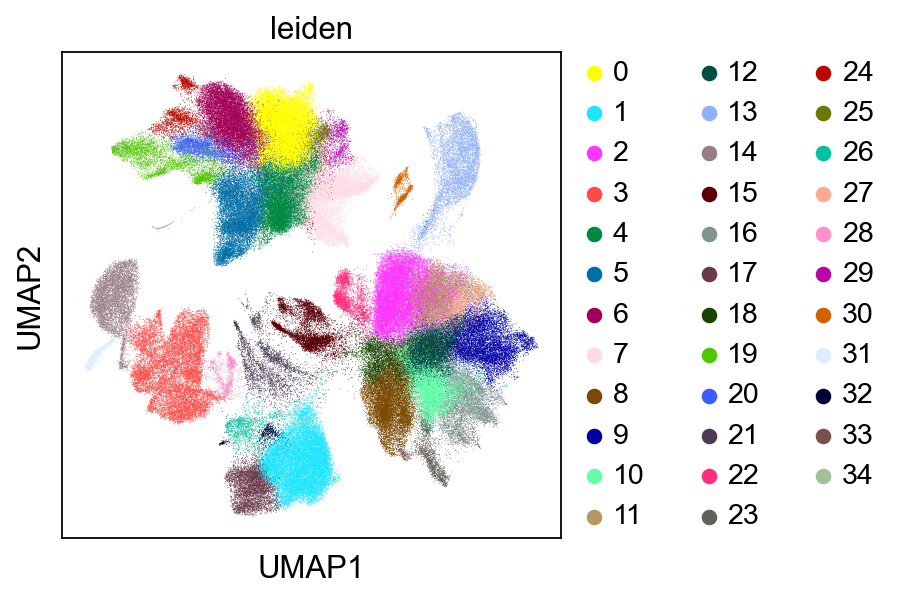

In [7]:
sc.pl.umap(imm_cell_data, color="leiden")

Not that theese clusters are not annotated to any cell type jet. We have amny way to annotate cell types to singel cell objects. Here because this is a known study we can just use the existing anntations.  

In [8]:
metadata = pd.read_table(folder + "Data//metadata//all.meta2.txt", sep="\t", header=0, index_col=0)
metadata.head()

C:\Users\modos\AppData\Local\Temp\ipykernel_21732\1925195177.py:1: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_table(folder + "Data//metadata//all.meta2.txt", sep="\t", header=0, index_col=0)


,Cluster,nGene,nUMI,Subject,Health,Location,Sample
NAME,,,,,,,
TYPE,group,numeric,numeric,group,group,group,group
N7.EpiA.AAACATACACACTG,TA 1,328,891,N7,Non-inflamed,Epi,N7.EpiA
N7.EpiA.AAACCGTGCATCAG,TA 1,257,663,N7,Non-inflamed,Epi,N7.EpiA
N7.EpiA.AAACGCACAATCGC,TA 2,300,639,N7,Non-inflamed,Epi,N7.EpiA
N7.EpiA.AAAGATCTAACCGT,Enterocyte Progenitors,250,649,N7,Non-inflamed,Epi,N7.EpiA


In [9]:
metadata = metadata[1:]

In [10]:
imm_cell_data.obs = imm_cell_data.obs.merge(metadata, how="left", left_index=True, right_index=True)

We can make umaps with the calcualted clusters and the cell types which was given by the authors they are more or less overalpping which makes a reasurance.

C:\ProgramData\Anaconda3\envs\scanpy_enveriomnet\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\ProgramData\Anaconda3\envs\scanpy_enveriomnet\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


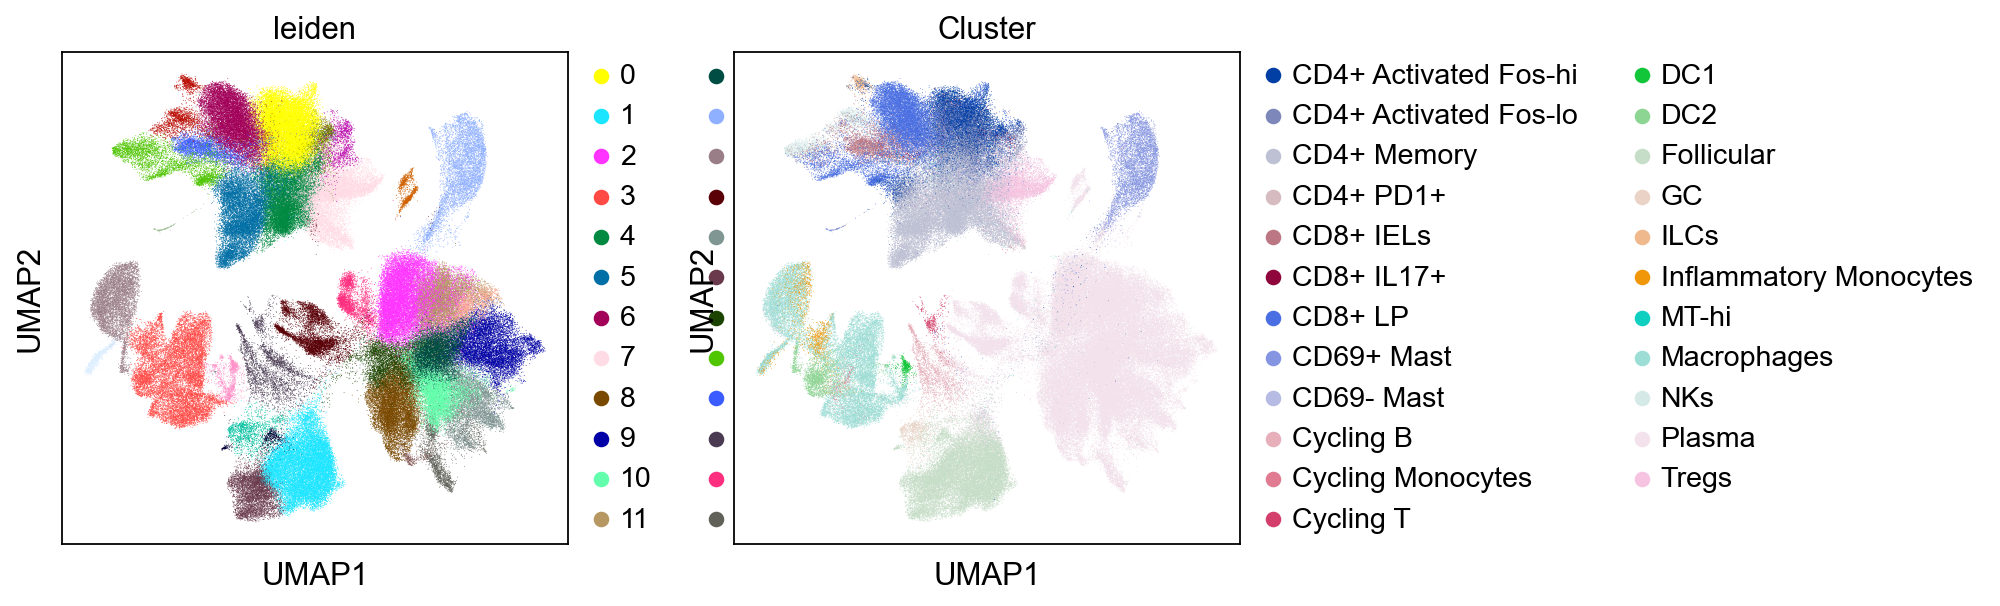

In [11]:
sc.pl.umap(imm_cell_data, color=["leiden", "Cluster"])

C:\ProgramData\Anaconda3\envs\scanpy_enveriomnet\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\ProgramData\Anaconda3\envs\scanpy_enveriomnet\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


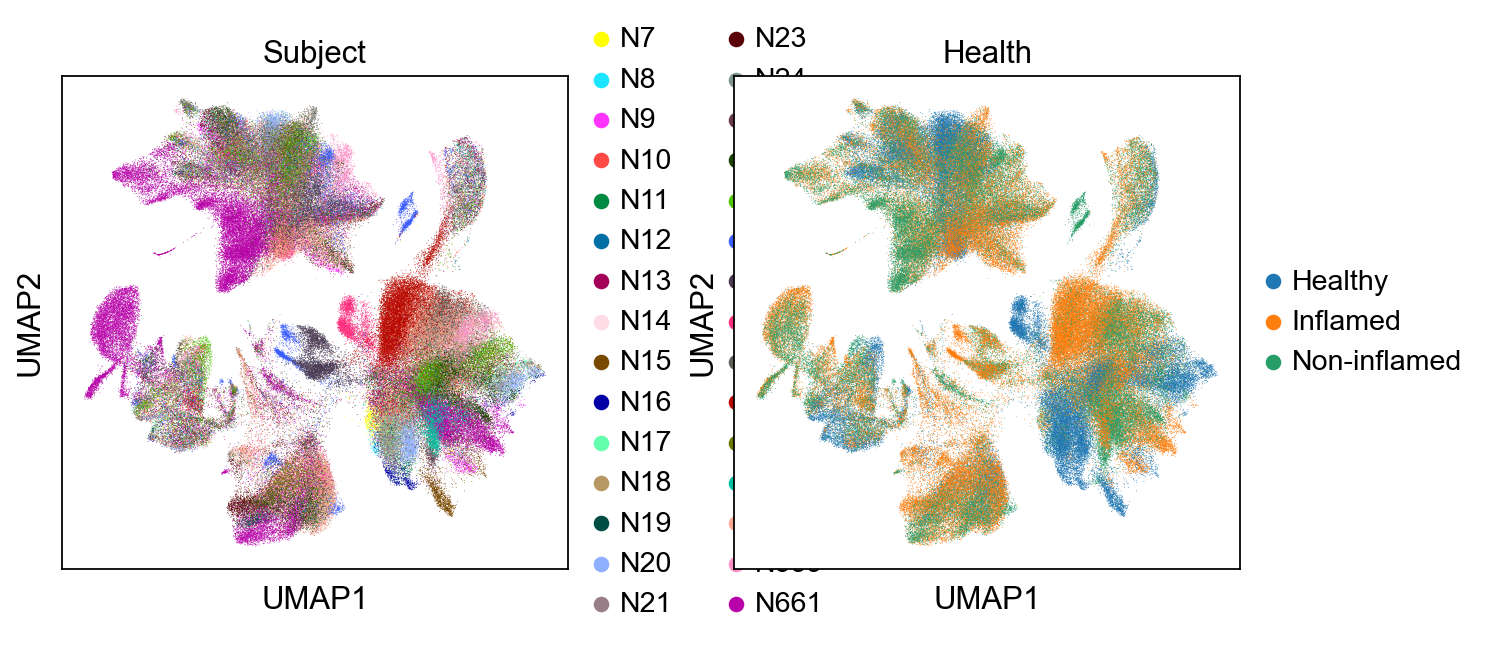

In [12]:
sc.pl.umap(imm_cell_data, color=["Subject", "Health"])

There are many ways to work forward.
1. Finding a proper cut off for the cells
2. Finding diferentially expressed genes between the various condtions
3. Calcuating a sum of the expression values as edge wheight

In [13]:
cell_types = list(set(imm_cell_data.obs["Cluster"]))

In [14]:
health_type= list(set(imm_cell_data.obs["Health"]))

In [15]:
cell_types

['CD4+ Activated Fos-lo',
 'GC',
 'Inflammatory Monocytes',
 'CD8+ LP',
 'ILCs',
 'Tregs',
 'CD8+ IELs',
 'Cycling Monocytes',
 'Plasma',
 'DC1',
 'Cycling T',
 'CD4+ PD1+',
 'NKs',
 'CD8+ IL17+',
 'Follicular',
 'CD69+ Mast',
 'MT-hi',
 'CD69- Mast',
 'Macrophages',
 'CD4+ Activated Fos-hi',
 'CD4+ Memory',
 'DC2',
 'Cycling B']

In [16]:
res_healthy = pd.DataFrame(columns=cell_types)
res_non_inflamed =pd.DataFrame(columns=cell_types)
res_inflamed = pd.DataFrame(columns=cell_types)

In [17]:
health_type

['Non-inflamed', 'Inflamed', 'Healthy']

In [18]:
healthy = imm_cell_data[imm_cell_data.obs['Health'] == "Healthy",:]
for clust in cell_types:
    res_healthy[clust] = healthy[healthy.obs['Cluster'] == clust].X.mean(0)
del(healthy)

In [19]:
non_inflamed = imm_cell_data[imm_cell_data.obs['Health'] == "Non-inflamed",:]
for clust in cell_types:
    print(clust)
    res_non_inflamed[clust] = non_inflamed[non_inflamed.obs['Cluster'] == clust].X.mean(0)
del(non_inflamed)

CD4+ Activated Fos-lo
GC
Inflammatory Monocytes
CD8+ LP
ILCs
Tregs
CD8+ IELs
Cycling Monocytes
Plasma
DC1
Cycling T
CD4+ PD1+
NKs
CD8+ IL17+
Follicular
CD69+ Mast
MT-hi
CD69- Mast
Macrophages
CD4+ Activated Fos-hi
CD4+ Memory
DC2
Cycling B


In [20]:
inflamed = imm_cell_data[imm_cell_data.obs['Health'] == "Inflamed",:]
for clust in cell_types:
    print(clust)
    res_inflamed[clust] = inflamed[inflamed.obs['Cluster'] == clust].X.mean(0)
del(inflamed)

CD4+ Activated Fos-lo
GC
Inflammatory Monocytes
CD8+ LP
ILCs
Tregs
CD8+ IELs
Cycling Monocytes
Plasma
DC1
Cycling T
CD4+ PD1+
NKs
CD8+ IL17+
Follicular
CD69+ Mast
MT-hi
CD69- Mast
Macrophages
CD4+ Activated Fos-hi
CD4+ Memory
DC2
Cycling B


<AxesSubplot: xlabel='NKs', ylabel='Count'>

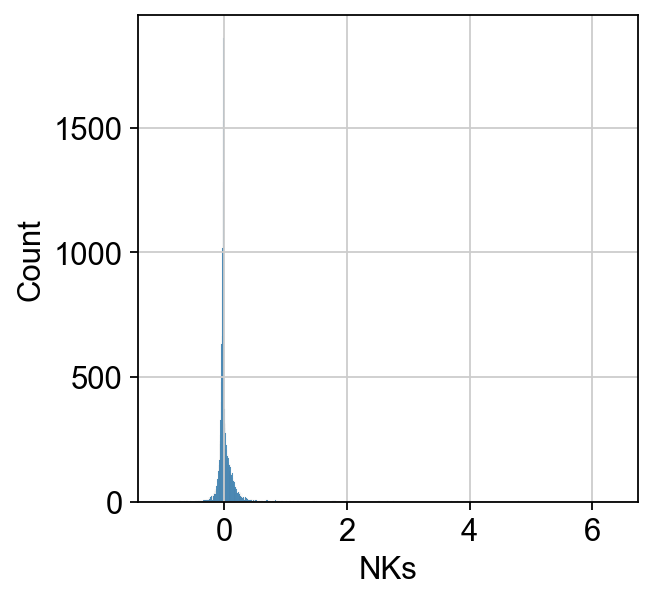

In [21]:
sns.histplot(res_inflamed["NKs"])

Calculating condotion specific means of average gene expression per cell type and also the stadard deviation of average gene expression per cell type.

In [22]:
mean_inf = res_inflamed.values.mean()
std_inf = res_inflamed.values.std()

mean_helth = res_healthy.values.mean()
std_helth = res_healthy.values.std()

mean_niuc = res_non_inflamed.values.mean()
std_niuc= res_non_inflamed.values.std()

In [23]:
mean_inf,std_inf, mean_helth,std_helth,mean_niuc,std_niuc 

(0.02741736, 0.20531943, 0.0037989188, 0.17986675, 0.03174851, 0.20733029)

In [39]:
values = res_inflamed.values.astype(float)
res_inflamed = pd.DataFrame(data=values, index=imm_cell_data.var_names, columns=res_inflamed.columns)

values = res_non_inflamed.values.astype(float)
res_non_inflamed = pd.DataFrame(data=values, index=imm_cell_data.var_names, columns=res_non_inflamed.columns)


In [40]:
values = res_healthy.values.astype(float)
res_healthy = pd.DataFrame(data=values, index=imm_cell_data.var_names, columns=res_healthy.columns)

In [26]:
res_inflamed[res_inflamed.values.astype(float)< mean_inf-std_inf] = "NaN"
res_healthy[res_healthy.values<mean_helth-std_helth] = "NaN"
res_non_inflamed[res_non_inflamed.values<mean_niuc-std_niuc] = "NaN"

In [27]:
import omnipath as op

In [28]:
intercell_network = op.interactions.import_intercell_network()

In [29]:
intercell_network.head()

,source,target,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,dip_url,curation_effort,references,...,category_source_intercell_target,uniprot_intercell_target,genesymbol_intercell_target,entity_type_intercell_target,consensus_score_intercell_target,transmitter_intercell_target,receiver_intercell_target,secreted_intercell_target,plasma_membrane_transmembrane_intercell_target,plasma_membrane_peripheral_intercell_target
0,P14416,P48995,True,False,True,True,False,None,1,TRIP:18261457,...,resource_specific,P48995,TRPC1,protein,1,False,True,False,False,False
1,P14416,P48995,True,False,True,True,False,None,1,TRIP:18261457,...,resource_specific,P48995,TRPC1,protein,3,False,True,False,False,False
2,P14416,P48995,True,False,True,True,False,None,1,TRIP:18261457,...,composite,P48995,TRPC1,protein,3,False,True,False,False,False
3,Q13255,P48995,True,False,True,True,False,None,1,TRIP:14614461,...,resource_specific,P48995,TRPC1,protein,1,False,True,False,False,False
4,Q13255,P48995,True,False,True,True,False,None,1,TRIP:14614461,...,resource_specific,P48995,TRPC1,protein,3,False,True,False,False,False


In [30]:
intercell_network.shape

(37606, 46)

In [31]:
intercell_network.columns

Index(['source', 'target', 'is_stimulation', 'is_inhibition',
       'consensus_direction', 'consensus_stimulation', 'consensus_inhibition',
       'dip_url', 'curation_effort', 'references', 'sources', 'type',
       'references_stripped', 'n_references', 'n_sources', 'n_primary_sources',
       'category_intercell_source', 'parent_intercell_source',
       'database_intercell_source', 'scope_intercell_source',
       'aspect_intercell_source', 'category_source_intercell_source',
       'uniprot_intercell_source', 'genesymbol_intercell_source',
       'entity_type_intercell_source', 'consensus_score_intercell_source',
       'transmitter_intercell_source', 'receiver_intercell_source',
       'secreted_intercell_source',
       'plasma_membrane_transmembrane_intercell_source',
       'plasma_membrane_peripheral_intercell_source',
       'category_intercell_target', 'parent_intercell_target',
       'database_intercell_target', 'scope_intercell_target',
       'aspect_intercell_target',

In [32]:
filtered_source_types = ["cell_surface_enzyme","cell_surface_ligand","ligand","secreted_enzyme","secreted_receptor",
           "adhesion","cell_adhesion","tight_junction","cell_surface_peptidase","gap_junction","desmosome"]
filtered_target_types = ["adhesion","receptor","cell_adhesion","tight_junction","gap_junction","ion_channel","transporter",
                "adherens_junction"]

In [33]:
filtered_intercell_network = intercell_network[intercell_network.category_intercell_source.isin(filtered_source_types)] 
filtered_intercell_network = filtered_intercell_network[filtered_intercell_network.
                                                        category_intercell_target.isin(filtered_target_types)]
filtered_intercell_network.shape

(24620, 46)

Let's say we will look into intercellular interactions between the plasma mebrane

Now we can choose 5 Cell type Let's say Dendrtitic cell 1, 2 and Treg cells

In [34]:
res_non_inflamed[["DC1","DC2","Tregs","CD4+ PD1+"]]

,DC1,DC2,Tregs,CD4+ PD1+
7SK,-0.001617,-0.004273,-0.066698,-0.071063
A1BG,-0.046877,0.008231,-0.029465,-0.046878
A1BG-AS1,0.028841,0.052843,0.035637,0.471321
A1CF,0.051269,0.000828,-0.022426,-0.022425
A2M,0.062751,0.381607,-0.146055,-0.011358
...,...,...,...,...
hsa-mir-5571,-0.027716,-0.027716,-0.027717,-0.027716
hsa-mir-6080,0.128471,0.276556,-0.045244,-0.071426
hsa-mir-8072,-0.038713,0.090853,0.017985,-0.10138
snoU109,-0.013932,-0.013932,-0.013931,-0.013932


In [35]:
DC1source = filtered_intercell_network[filtered_intercell_network.genesymbol_intercell_source.isin(res_non_inflamed[res_non_inflamed["DC1"].notna()].index)]

In [36]:
DC1source.shape

(20301, 46)

In [41]:
len(res_non_inflamed[res_non_inflamed["DC1"]>0.0].index)

10469

In [43]:
DC1DC2 = DC1source[DC1source.genesymbol_intercell_target.isin(res_non_inflamed[res_non_inflamed["DC2"].notna()].index)]

In [44]:
DC1DC2.shape

(16101, 46)

In [45]:
DC1DC2.head()

,source,target,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,dip_url,curation_effort,references,...,category_source_intercell_target,uniprot_intercell_target,genesymbol_intercell_target,entity_type_intercell_target,consensus_score_intercell_target,transmitter_intercell_target,receiver_intercell_target,secreted_intercell_target,plasma_membrane_transmembrane_intercell_target,plasma_membrane_peripheral_intercell_target
9,P23560,P48995,True,False,True,True,False,None,0,NaN,...,resource_specific,P48995,TRPC1,protein,1,False,True,False,False,False
10,P23560,P48995,True,False,True,True,False,None,0,NaN,...,resource_specific,P48995,TRPC1,protein,3,False,True,False,False,False
11,P23560,P48995,True,False,True,True,False,None,0,NaN,...,composite,P48995,TRPC1,protein,3,False,True,False,False,False
13,P11229,P04899,False,False,False,False,False,None,1,HPRD:8190105,...,resource_specific,P04899,GNAI2,protein,1,False,True,False,False,False
15,P08069,P04899,False,False,False,False,False,None,1,HPRD:11120746,...,resource_specific,P04899,GNAI2,protein,1,False,True,False,False,False


In [46]:
unique_interactions = DC1DC2[["genesymbol_intercell_source", "genesymbol_intercell_target"]].value_counts().reset_index(name='count')

In [47]:
unique_interactions.shape

(6990, 3)

In [48]:
cell_types = ["DC1","DC2","Tregs","CD4+ PD1+"]
outcome_tupple_list = []
for cell_type1 in cell_types:
    expressed_genes_source = res_non_inflamed[res_non_inflamed[cell_type1]>0.0].index
    source_network = filtered_intercell_network[filtered_intercell_network.genesymbol_intercell_source.isin(expressed_genes_source)]      
    for cell_type2 in cell_types:
        if cell_type1 != cell_type2:
            expressed_genes_target = res_non_inflamed[res_non_inflamed[cell_type2]>0.0].index
            intercell_network = source_network[source_network.genesymbol_intercell_target.isin(expressed_genes_target)]      
            unique_interactions = intercell_network[["genesymbol_intercell_source", "genesymbol_intercell_target"]].value_counts().reset_index(name='count')
            outcome_tupple_list.append((cell_type1, cell_type2, unique_interactions.shape[0]))
            


In [49]:
outcome_tupple_list

[('DC1', 'DC2', 1470),
 ('DC1', 'Tregs', 741),
 ('DC1', 'CD4+ PD1+', 530),
 ('DC2', 'DC1', 1323),
 ('DC2', 'Tregs', 918),
 ('DC2', 'CD4+ PD1+', 658),
 ('Tregs', 'DC1', 618),
 ('Tregs', 'DC2', 874),
 ('Tregs', 'CD4+ PD1+', 350),
 ('CD4+ PD1+', 'DC1', 437),
 ('CD4+ PD1+', 'DC2', 602),
 ('CD4+ PD1+', 'Tregs', 350)]

In [50]:
import igraph as ig

In [51]:
uc_uninf = ig.Graph.TupleList(outcome_tupple_list, weights=True, directed=True)

In [52]:
visual_style = {}

In [53]:
# Curve the edges
visual_style["edge_curved"] = True
# Set the layout
my_layout = uc_uninf.layout_circle(order=["DC1","DC2","Tregs","CD4+ PD1+"])
visual_style["layout"] = my_layout
#Add annoation
visual_style["vertex_label"] = uc_uninf.vs["name"]
#Calcualte the edge wheight relative the number of edges
visual_style["edge_width"] = 0.01 * np.array(uc_uninf.es["weight"])

#Setting the vertex visualistation parameters -colours and label position
visual_style["vertex_label_size"] = 30
visual_style["vertex_color"] = "grey"
visual_style["vertex_label_dist"] = 0.75
visual_style["vertex_size"] = 40

#Setting the edge visualisation parameters
visual_style["edge_color"] = "#004C66" #hexa code for blue
visual_style["edge_arrow_size"] = 2

#Setting the visualistation place. igraph need margin yo work
visual_style["bbox"] = (600, 600)
visual_style["margin"] = 100

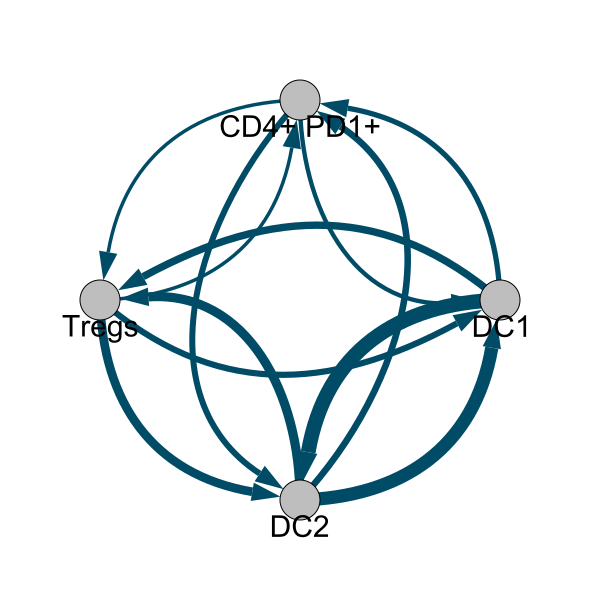

In [54]:
ig.plot(uc_uninf, "uc_pandas.png", **visual_style)